In [7]:
import json
import pandas as pd
from tqdm import tqdm
import re
import numpy as np
import matplotlib.pyplot as plt


## Process LLM Drug Indications

In [188]:
llm_indications = pd.read_csv("./drugs_with_indications_LLM_cleaned.csv")

In [190]:
llm_indications_data = llm_indications[['unique_id', 'drug_term_umls_norm_manual_clean', 'year','application_number', 'active_ingredients_split', 'disease_from_indications']]

In [191]:
llm_indications_data

,unique_id,drug_term_umls_norm_manual_clean,year,application_number,active_ingredients_split,disease_from_indications
0,dexamethasone_ANDA088248,Dexamethasone,1983.0,ANDA088248,DEXAMETHASONE,asthma|atopic dermatitis|contact dermatitis|dr...
1,dexamethasone_NDA050592,Dexamethasone,1988.0,NDA050592,DEXAMETHASONE,steroid-responsive inflammatory ocular conditi...
2,dexamethasone_ANDA062938,Dexamethasone,1989.0,ANDA062938,DEXAMETHASONE,steroid-responsive inflammatory ocular conditi...
3,dexamethasone_ANDA064135,Dexamethasone,1995.0,ANDA064135,DEXAMETHASONE,steroid-responsive inflammatory ocular conditi...
4,dexamethasone_ANDA080399,Dexamethasone,1971.0,ANDA080399,DEXAMETHASONE,asthma|atopic dermatitis|contact dermatitis|dr...
...,...,...,...,...,...,...
8047,uridine_triacetate_NDA208159,URIDINE TRIACETATE,2015.0,NDA208159,URIDINE TRIACETATE,cardiac toxicity|central nervous system toxici...
8048,uridine_triacetate_NDA208169,URIDINE TRIACETATE,2015.0,NDA208169,URIDINE TRIACETATE,hereditary orotic aciduria
8049,umeclidinium_bromide_NDA203975,Umeclidinium bromide,2013.0,NDA203975,UMECLIDINIUM BROMIDE,chronic obstructive pulmonary disease|COPD
8050,umeclidinium_bromide_NDA209482,Umeclidinium bromide,2017.0,NDA209482,UMECLIDINIUM BROMIDE,chronic obstructive pulmonary disease|COPD


In [194]:
llm_indications_data[llm_indications_data['drug_term_umls_norm_manual_clean']=="Cladribine"]

,unique_id,drug_term_umls_norm_manual_clean,year,application_number,active_ingredients_split,disease_from_indications
5017,cladribine_NDA022561,Cladribine,2019.0,NDA022561,CLADRIBINE,relapsing forms of multiple sclerosis|relapsin...
5018,cladribine_ANDA075405,Cladribine,2000.0,ANDA075405,CLADRIBINE,Hairy Cell Leukemia|anemia|neutropenia|thrombo...
5019,cladribine_ANDA076571,Cladribine,2004.0,ANDA076571,CLADRIBINE,Hairy Cell Leukemia|anemia|neutropenia|thrombo...
5020,cladribine_ANDA210856,Cladribine,2019.0,ANDA210856,CLADRIBINE,Hairy Cell Leukemia|anemia|neutropenia|thrombo...


In [195]:
#1. Split disease list into one row per disease
df_expanded = (
    llm_indications_data.assign(disease=llm_indications_data['disease_from_indications'].str.split('|'))
      .explode('disease')
      .dropna(subset=['disease'])
)

# 2. Aggregate: earliest year + list of all associated documents
result = (
    df_expanded
    .groupby(['drug_term_umls_norm_manual_clean', 'disease'], as_index=False)
    .agg(
        earliest_year=('year', 'min'),
        documents=('application_number', lambda x: sorted(set(x)))
    )
)
result

,drug_term_umls_norm_manual_clean,disease,earliest_year,documents
0,ANAKINRA,CAPS,2001.0,[BLA103950]
1,ANAKINRA,Cryopyrin-Associated Periodic Syndromes,2001.0,[BLA103950]
2,ANAKINRA,DIRA,2001.0,[BLA103950]
3,ANAKINRA,Deficiency of Interleukin-1 Receptor Antagonist,2001.0,[BLA103950]
4,ANAKINRA,NOMID,2001.0,[BLA103950]
...,...,...,...,...
4907,zolmitriptan,migraine with aura,2013.0,"[ANDA201779, ANDA204041, ANDA207021, ANDA207867]"
4908,zolmitriptan,migraine with or without aura,2013.0,"[ANDA202560, ANDA202890, ANDA202956, ANDA20428..."
4909,zolmitriptan,migraine without aura,2013.0,"[ANDA201779, ANDA204041, ANDA207021, ANDA207867]"
4910,zuranolone,PPD,2023.0,[NDA217369]


In [206]:
result[result['drug_term_umls_norm_manual_clean'].str.contains("cladribine", case=False)]


,drug_term_umls_norm_manual_clean,disease,earliest_year,documents
873,Cladribine,Hairy Cell Leukemia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
874,Cladribine,active secondary progressive disease,2019.0,[NDA022561]
875,Cladribine,anemia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
876,Cladribine,disease-related symptoms,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
877,Cladribine,neutropenia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"
878,Cladribine,relapsing forms of multiple sclerosis,2019.0,[NDA022561]
879,Cladribine,relapsing-remitting disease,2019.0,[NDA022561]
880,Cladribine,thrombocytopenia,2000.0,"[ANDA075405, ANDA076571, ANDA210856]"


In [205]:
result[result['disease'].str.contains("schizophrenia", case=False)]


,drug_term_umls_norm_manual_clean,disease,earliest_year,documents
13,ARIPiprazole,Schizophrenia,2002.0,"[ANDA201519, ANDA202101, ANDA202547, ANDA20302..."
22,ARIPiprazole,schizophrenia,2013.0,"[ANDA202102, NDA202971, NDA207202, NDA216655, ..."
274,Asenapine,schizophrenia,2019.0,[NDA212268]
492,Brexpiprazole,schizophrenia,2015.0,"[ANDA213562, NDA205422]"
941,Clozapine,schizophrenia,1989.0,"[ANDA090308, ANDA201824, ANDA202873, ANDA21292..."
942,Clozapine,treatment-resistant schizophrenia,1999.0,"[ANDA075417, ANDA075713, ANDA206433]"
1686,Fluphenazine decanoate,chronic schizophrenia,1996.0,[ANDA074531]
1687,Fluphenazine decanoate,schizophrenia,1987.0,"[ANDA071413, ANDA075918, ANDA203732, ANDA20773..."
2022,Iloperidone,schizophrenia,2009.0,"[ANDA207231, NDA022192]"
2678,OLANZapine,Schizophrenia,2021.0,[NDA213378]


## FDA Website NMA data

In [211]:
all_years_df = pd.read_csv("out/NME_drugs_with_indications_LLM_cleaned_manual_val.csv")
all_years_df["is_neuro"] = all_years_df["Neuro-related (True/False)"].str.lower().str.contains("true")

all_years_df.head()

,no,drug_name,active_ingredient,approval_date,fda_use_on_approval,drug_url,year,indications_first_sent,indications_and_usage,disease_from_indications,Disease / Condition,Neuro-related (True/False),is_neuro
0,45.0,Zurampic,lesinurad,12/22/15 0:00,To treat high blood uric acid levels associate...,https://web.archive.org/web/20240428045412/htt...,2015,To treat high blood uric acid levels associate...,To treat high blood uric acid levels associate...,hyperuricemia|gout|acute arthritis of gout|uri...,hyperuricemia / gout / acute arthritis of gout...,FALSE,False
1,44.0,Uptravi,selexipag,12/21/15 0:00,To treat pulmonary arterial hypertension Drug ...,https://web.archive.org/web/20240428045412/htt...,2015,To treat pulmonary arterial hypertension Drug ...,To treat pulmonary arterial hypertension Drug ...,pulmonary arterial hypertension,pulmonary arterial hypertension,FALSE,False
2,43.0,Bridion,sugammadex,12/15/15 0:00,To reverse effects of neuromuscular blocking d...,https://web.archive.org/web/20240428045412/htt...,2015,To reverse effects of neuromuscular blocking d...,To reverse effects of neuromuscular blocking d...,neuromuscular blockade,neuromuscular blockade,TRUE,True
3,42.0,Alecensa,alectinib,12/11/15 0:00,To treat ALK-positive lung cancer Drug Trials ...,https://web.archive.org/web/20240428045412/htt...,2015,To treat ALK-positive lung cancer Drug Trials ...,To treat ALK-positive lung cancer Drug Trials ...,ALK-positive lung cancer,ALK-positive lung cancer,FALSE,False
4,41.0,Kanuma,sebelipase alfa,12/8/15 0:00,To treat patients with a rare disease known as...,https://web.archive.org/web/20240428045412/htt...,2015,To treat patients with a rare disease known as...,To treat patients with a rare disease known as...,lysosomal acid lipase deficiency,lysosomal acid lipase deficiency,FALSE,False


In [235]:
total_rows = len(all_years_df)
num_neuro = all_years_df["is_neuro"].sum()
num_non_neuro = total_rows - num_neuro
prop_neuro = num_neuro / total_rows

print("------ Neuro Approval Statistics ------")
print(f"Total drug approvals in dataset: {total_rows}")
print(f"Neuro-related approvals:         {num_neuro}")
print(f"Non-neuro approvals:             {num_non_neuro}")
print(f"Proportion neuro-related:        {prop_neuro:.3f} ({prop_neuro*100:.1f}%)")


------ Neuro Approval Statistics ------
Total drug approvals in dataset: 602
Neuro-related approvals:         115
Non-neuro approvals:             487
Proportion neuro-related:        0.191 (19.1%)


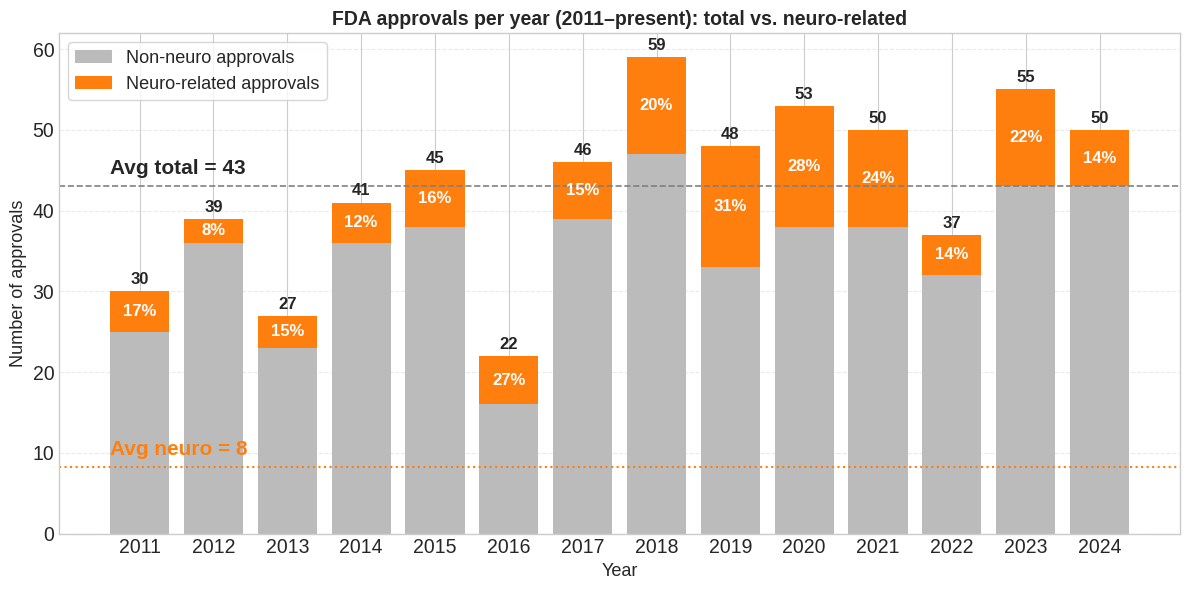

In [229]:
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure dtypes & clean ---
all_years_df["year"] = pd.to_numeric(all_years_df["year"], errors="coerce").astype("Int64")
all_years_df["is_neuro"] = all_years_df["is_neuro"].fillna(False).astype(bool)

df_neuro = all_years_df.copy()

# Drop rows with missing year
df_neuro = df_neuro.dropna(subset=["year"])
min_year = df_neuro['year'].min()
# --- Aggregate per year ---
yearly = (
    df_neuro.groupby("year")
    .agg(
        total=("is_neuro", "size"),
        neuro=("is_neuro", "sum")
    )
    .dropna(subset=["total"])
    .sort_index()
)

yearly["non_neuro"] = yearly["total"] - yearly["neuro"]

# --- Averages over the period (optional) ---
avg_total = yearly["total"].mean()
avg_neuro = yearly["neuro"].mean()

# --- Prep arrays for plotting ---
years = yearly.index.astype("int64").to_numpy()
x = np.arange(len(years))
total = yearly["total"].to_numpy()
non_neuro = yearly["non_neuro"].to_numpy()
neuro = yearly["neuro"].to_numpy()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

# Stacked bars: non-neuro at bottom, neuro on top
ax.bar(x, non_neuro, label="Non-neuro approvals", color="#BBBBBB")
ax.bar(x, neuro, bottom=non_neuro, label="Neuro-related approvals", color="tab:orange") #"#4682B4"

# Total numbers on top of each bar
for xi, tot in zip(x, total):
    ax.text(
        xi, tot + 0.5,
        f"{int(tot)}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

# Neuro proportion (%) inside the neuro segment
for xi, base, nv, tot in zip(x, non_neuro, neuro, total):
    if nv > 0 and tot > 0:
        prop = nv / tot
        ax.text(
            xi, base + nv / 2,
            f"{prop:.0%}",
            ha="center", va="center",
            fontsize=12, color="white", fontweight="bold"
        )

# Average lines (optional, like your other plot)
ax.axhline(avg_total, color="gray", linestyle="--", linewidth=1.2)
ax.text(
    -0.4, avg_total + 1,
    f"Avg total = {avg_total:.0f}",
    va="bottom", fontsize=15, fontweight="bold"
)

ax.axhline(avg_neuro, color="tab:orange", linestyle=":", linewidth=1.5)
ax.text(
    -0.4, avg_neuro + 1,
    f"Avg neuro = {avg_neuro:.0f}",
    va="bottom", color="tab:orange", fontsize=15, fontweight="bold"
)

# Labels & style
ax.set_title(
    f"FDA approvals per year ({min_year}–present): total vs. neuro-related",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of approvals", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in years],)
ax.tick_params(axis="both", labelsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=True, fontsize=13)

plt.tight_layout()
plt.show()


In [232]:
all_years_df_neuro = all_years_df[all_years_df["is_neuro"]]

In [234]:
all_years_df_neuro = all_years_df_neuro[['drug_name','active_ingredient','year','disease_from_indications']]
all_years_df_neuro

,drug_name,active_ingredient,year,disease_from_indications
2,Bridion,sugammadex,2015,neuromuscular blockade
17,Aristada,aripiprazole lauroxil,2015,schizophrenia
20,Vraylar,cariprazine,2015,schizophrenia|bipolar disorder
24,Addyi,flibanserin,2015,"acquired, generalized hypoactive sexual desire..."
28,Rexulti,brexpiprazole,2015,schizophrenia|major depressive disorder| depre...
...,...,...,...,...
577,Plegridy,peginterferon beta-1a,2014,relapsing forms of multiple sclerosis|multiple...
578,Belsomra,suvorexant,2014,insomnia
589,Zontivity,vorapaxar,2014,stroke
598,Northera,droxidopa,2014,neurogenic orthostatic hypotension


In [237]:
approved_neuro_after_2015 = all_years_df_neuro[all_years_df_neuro['year']>=2015]

In [248]:
approved_neuro_after_2015.to_csv("out/approved_neuro_after_2015.csv", index=False)

In [250]:
approved_neuro_after_2015 = pd.read_csv("out/approved_neuro_after_2015_manual_clean.csv")
approved_neuro_after_2015

,drug_name,active_ingredient,year,disease_from_indications,disease_from_indications_clean
0,Bridion,sugammadex,2015,neuromuscular blockade,neuromuscular blockade
1,Aristada,aripiprazole lauroxil,2015,schizophrenia,schizophrenia
2,Vraylar,cariprazine,2015,schizophrenia|bipolar disorder,schizophrenia|bipolar disorder
3,Addyi,flibanserin,2015,"acquired, generalized hypoactive sexual desire...",hypoactive sexual desire disorder
4,Rexulti,brexpiprazole,2015,schizophrenia|major depressive disorder| depre...,schizophrenia|depression
...,...,...,...,...,...
93,Miplyffa,arimoclomol,2024,Niemann-Pick disease type C,Niemann-Pick disease type C
94,Voranigo,vorasidenib,2024,Grade 2 astrocytoma|oligodendroglioma,Grade 2 astrocytoma|oligodendroglioma
95,Kisunla,donanemab-azbt,2024,Alzheimer's disease,Alzheimers disease
96,Ojemda,tovorafenib,2024,relapsed or refractory pediatric low-grade gli...,glioma


In [269]:
df_exp = (
    approved_neuro_after_2015
    .assign(disease_from_indications_clean =
            approved_neuro_after_2015["disease_from_indications_clean"].str.split("|"))
    .explode("disease_from_indications_clean")
)

# clean whitespace + remove apostrophes + lowercase
df_exp["disease_from_indications_clean"] = (
    df_exp["disease_from_indications_clean"]
    .str.replace("'", "", regex=False)
    .str.strip()
    .str.lower()
)


In [270]:
# --- Stats ---
unique_drugs = df_exp["active_ingredient"].nunique()
unique_diseases = df_exp["disease_from_indications_clean"].nunique()
unique_pairs = df_exp[["active_ingredient", "disease_from_indications_clean"]].drop_duplicates().shape[0]

print("------ Stats for Neuro-Drugs since 2015 ------")
print(f"Unique active_ingredient:              {unique_drugs}")
print(f"Unique diseases:           {unique_diseases}")
print(f"Unique drug–disease pairs: {unique_pairs}")

------ Stats for Neuro-Drugs since 2015 ------
Unique active_ingredient:              98
Unique diseases:           63
Unique drug–disease pairs: 123


In [278]:
drug_column = "active_ingredient"

# clean whitespace + remove apostrophes
df_exp["disease_from_indications_clean"] = (
    df_exp["disease_from_indications_clean"]
    .str.strip()
    .str.replace("'", "", regex=False)
)

# --- Frequency of diseases ---
disease_counts = (
    df_exp["disease_from_indications_clean"]
    .value_counts()
    .reset_index()
)
disease_counts.columns = ["disease", "count"]

# --- Unique drugs (active ingredients) per disease ---
disease_unique_drugs = (
    df_exp.groupby("disease_from_indications_clean")[drug_column]
    .nunique()
    .reset_index()
    .rename(columns={
        "disease_from_indications_clean": "disease",
        drug_column: "unique_drugs"   # or "unique_active_ingredients" if you prefer
    })
)

# --- Unique drug–disease pairs (active ingredient – disease) ---
disease_unique_pairs = (
    df_exp[["disease_from_indications_clean", drug_column]]
    .drop_duplicates()
    .groupby("disease_from_indications_clean")
    .size()
    .reset_index(name="unique_pairs")
    .rename(columns={"disease_from_indications_clean": "disease"})
)

# --- Merge into one summary table ---
disease_summary = (
    disease_counts
    .merge(disease_unique_drugs, on="disease")
    .merge(disease_unique_pairs, on="disease")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# --- Build list of active ingredients per disease ---

pairs = (
    df_exp[["disease_from_indications_clean", drug_column, "year"]]
    .sort_values("year")      
    .drop_duplicates(subset=["disease_from_indications_clean", drug_column], keep="first")
    .rename(columns={
        "disease_from_indications_clean": "disease",
        drug_column: "drug",
        "year": "FDA_approval_year"
    })
)


drugs_per_disease = (
    pairs.groupby("disease")["drug"]
    .apply(lambda s: ", ".join(sorted(s.unique())))  # comma-separated list
    .reset_index(name="drugs")
)

disease_summary_with_drugs = (
    disease_summary
    .merge(drugs_per_disease, on="disease", how="left")
)

disease_summary_with_drugs.head(10)


,disease,count,unique_drugs,unique_pairs,drugs
0,migraine,9,9,9,"atogepant, eptinezumab-jjmr, erenumab-aooe, fr..."
1,duchenne muscular dystrophy,7,7,7,"casimersen, deflazacort, eteplirsen, givinosta..."
2,multiple sclerosis,6,6,6,"daclizumab, ocrelizumab, ozanimod, ponesimod, ..."
3,schizophrenia,6,6,6,"aripiprazole lauroxil, brexpiprazole, caripraz..."
4,parkinsons disease,5,5,5,"fluorodopa F 18, istradefylline, opicapone, pi..."
5,alzheimers disease,4,4,4,"aducanumab - avwa, donanemab-azbt, flortaucipi..."
6,amyloidosis,4,4,4,"eplontersen, inotersen, patisiran, vutrisiran"
7,neuroendocrine tumors,4,4,4,"Ga-68-DOTATOC, copper Cu 64 dotatate injection..."
8,seizures,4,4,4,"brivaracetam, cenobamate, ganaxolone, stiripentol"
9,depression,4,4,4,"brexanolone, brexpiprazole, gepirone, zuranolone"


In [279]:
pairs

,disease,drug,FDA_approval_year
0,neuromuscular blockade,sugammadex,2015
6,venous thromboembolism,edoxaban,2015
6,atrial fibrillation,edoxaban,2015
6,systemic embolism,edoxaban,2015
5,neuroblastoma,dinutuximab,2015
...,...,...,...
93,niemann-pick disease type c,arimoclomol,2024
94,grade 2 astrocytoma,vorasidenib,2024
94,oligodendroglioma,vorasidenib,2024
95,alzheimers disease,donanemab-azbt,2024


In [287]:
pairs.to_csv("out/FDA_neuro_drug_disease_pairs_after_2015.csv",index=False)

## linking to ontologies

In [1]:
import sys
sys.path.append("../04_normalization")   # adjust path to your real folder
from neural_based_nen import main


In [2]:
data_dir =  "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/"

In [3]:
mapping_type = "disease"
col_to_map = "disease"
input_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015.csv"
output_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease.csv"

main(mapping_type, col_to_map, data_dir, input_file, output_file, stats_dir=None)

Input file: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015.csv


/home/sdonev/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Using terminology: mondo
Using distance threshold: 9.65
Starting normalization for: DISEASE with cdist 9.65
Loading embeddings from /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mondo/embeddings with prefix MONDO_emb...
Loading term-id pairs from /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mondo/mondo_term_id_pairs.json...
No COMBINED embeddings file found, loading all batch files...
Loaded embeddings: torch.Size([129189, 768]), term_id_pairs: 129189, canonical mappings: 30084
Found 63 unique terms in 'disease'


Mapping disease NER to mondo: 100%|██████████| 123/123 [00:00<00:00, 9957.53it/s]

Normalization time for 'disease': 0:00:03
Output saved to: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease.csv


In [5]:
mapping_type = "drug"
col_to_map = "drug"
input_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015.csv"
output_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_drug.csv"

main(mapping_type, col_to_map, data_dir, input_file, output_file, stats_dir=None)

Input file: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015.csv


/home/sdonev/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Using terminology: umls
Using distance threshold: 8.2
Starting normalization for: DRUG with cdist 8.2
Loading embeddings from /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/umls/embeddings with prefix UMLS_emb...
Loading term-id pairs from /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/umls/umls_term_id_pairs_combined.json...
Found COMBINED embeddings file, loading that one...
Loaded embeddings: torch.Size([1315534, 768]), term_id_pairs: 1315534, canonical mappings: 474316
Found 98 unique terms in 'drug'


Mapping drug NER to umls: 100%|██████████| 123/123 [00:00<00:00, 10532.43it/s]

Normalization time for 'drug': 0:00:31
Output saved to: /scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_drug.csv


In [8]:
df_disease_linked = pd.read_csv("/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease.csv")
df_drug_linked = pd.read_csv("/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_drug.csv")
df_orig = pd.read_csv("/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015.csv")

In [9]:
df_disease_linked.shape, df_drug_linked.shape, df_orig.shape

((123, 6), (123, 6), (123, 3))

In [13]:
df_orig_keep = df_orig[['FDA_approval_year']]
df_combined = pd.concat([df_orig_keep, df_disease_linked, df_drug_linked], axis=1)
df_combined.to_csv("out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease_drug.csv", index=False)